<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# Load Digits Dataset-done
#         ↓
# Visualize Images-done
#         ↓
# Train/Test Split-done
#         ↓
# Feature Scaling-done
#         ↓
# Train Linear SVM-done
#         ↓
# Train Polynomial SVM-done
#         ↓
# Train RBF SVM-done
#         ↓
# Compare Accuracy / Precision / Recall / F1-done
#         ↓
# Confusion Matrix-done
#         ↓
# Tune C, degree, gamma-done
#         ↓
# Final Comparison-done

In [44]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

pd.Series(y).value_counts()
df=pd.DataFrame(X)

In [46]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [47]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1797 non-null   float64
 1   1       1797 non-null   float64
 2   2       1797 non-null   float64
 3   3       1797 non-null   float64
 4   4       1797 non-null   float64
 5   5       1797 non-null   float64
 6   6       1797 non-null   float64
 7   7       1797 non-null   float64
 8   8       1797 non-null   float64
 9   9       1797 non-null   float64
 10  10      1797 non-null   float64
 11  11      1797 non-null   float64
 12  12      1797 non-null   float64
 13  13      1797 non-null   float64
 14  14      1797 non-null   float64
 15  15      1797 non-null   float64
 16  16      1797 non-null   float64
 17  17      1797 non-null   float64
 18  18      1797 non-null   float64
 19  19      1797 non-null   float64
 20  20      1797 non-null   float64
 21  21      1797 non-null   float64
 22  

In [49]:
df.isna().sum().sum()

np.int64(0)

In [50]:
df.duplicated().sum()

np.int64(0)

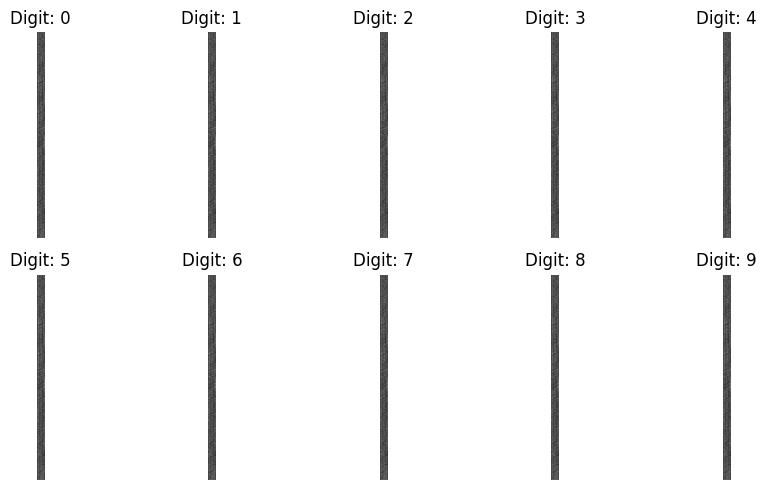

In [51]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, image, label in zip(axes.ravel(), X, y):
    ax.imshow(X, cmap='gray')
    ax.set_title(f"Digit: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

0.975


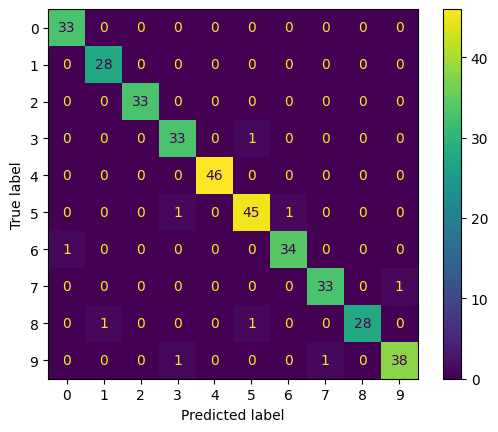

In [53]:
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train_scaled, y_train)

y_pred = linear_svm.predict(X_test_scaled)
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [54]:
# X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
#     digits.data,
#     digits.target,
#     digits.images,
#     test_size=0.2,
#     random_state=42,
#     stratify=digits.target
# )
# fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# for ax, image, actual, predicted in zip(
#     axes.ravel(),
#     img_test[:10],
#     y_test[:10],
#     y_pred[:10]
# ):
#     ax.imshow(image, cmap='gray')
#     ax.set_title(f"Actual: {actual}\nPred: {predicted}")
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

0.975


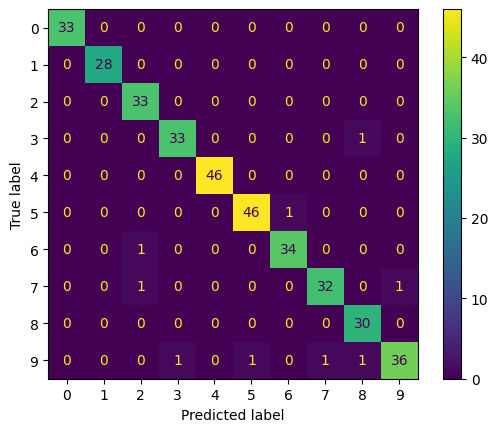

In [55]:
poly_svm = SVC(kernel='poly', degree=2)

poly_svm.fit(X_train_scaled, y_train)

y_pred_poly = poly_svm.predict(X_test_scaled)

print(accuracy_score(y_test, y_pred_poly))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_poly)
plt.show()

0.9861111111111112


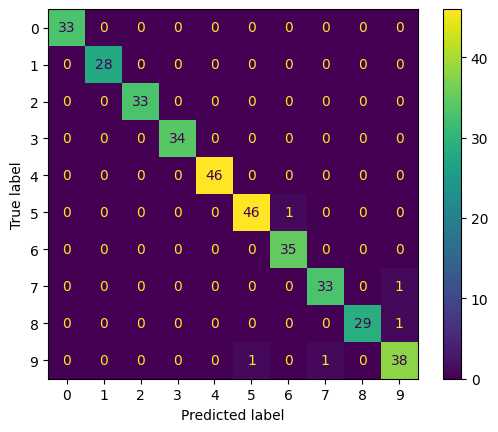

0.9868277979964809
0.9871533861771657
0.9865978306216103


array([[33,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 28,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 33,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 34,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 46,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 46,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 35,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 33,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 29,  1],
       [ 0,  0,  0,  0,  0,  1,  0,  1,  0, 38]])

In [64]:
rbf_test = SVC(kernel='rbf')

rbf_test.fit(X_train, y_train)

pred_test = rbf_test.predict(X_test)

print(accuracy_score(y_test, pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, pred_test)
plt.show()
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print(f1_score(y_test, pred_test, average='macro'))
print(precision_score(y_test, pred_test, average='macro'))
print(recall_score(y_test, pred_test, average='macro'))
confusion_matrix = confusion_matrix(y_test, pred_test)
confusion_matrix

0.9805555555555555


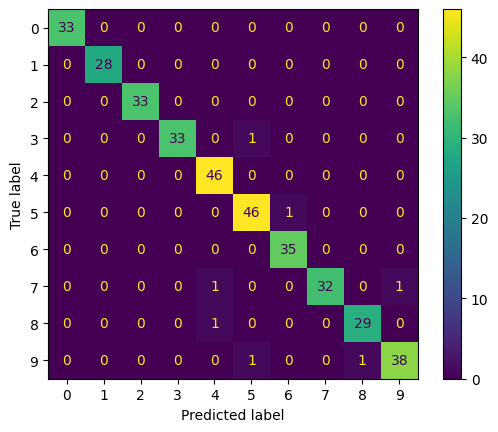

0.9816523529529648
0.9829914529914531
0.9807154776804337


In [63]:
rbf_test2 = SVC(kernel='rbf')

rbf_test2.fit(X_train_scaled, y_train)

pred_test1 = rbf_test2.predict(X_test_scaled)

print(accuracy_score(y_test, pred_test1))

ConfusionMatrixDisplay.from_predictions(y_test, pred_test1)
plt.show()
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print(f1_score(y_test, pred_test1, average='macro'))
print(precision_score(y_test, pred_test1, average='macro'))
print(recall_score(y_test, pred_test1, average='macro'))
confusion_matrix = confusion_matrix(y_test, pred_test1)


In [65]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)

X_2D = pca.fit_transform(X_train_scaled)
linear_2d = SVC(kernel='linear')
linear_2d.fit(X_2D, y_train)

poly_2d = SVC(kernel='poly', degree=2)
poly_2d.fit(X_2D, y_train)

SVC(degree=2, kernel='poly')

In [66]:
def plot_svm_boundary(model, X, y, title):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(9, 6))

    plt.contourf(xx, yy, Z, alpha=0.2)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        s=15
    )

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)

    plt.show()

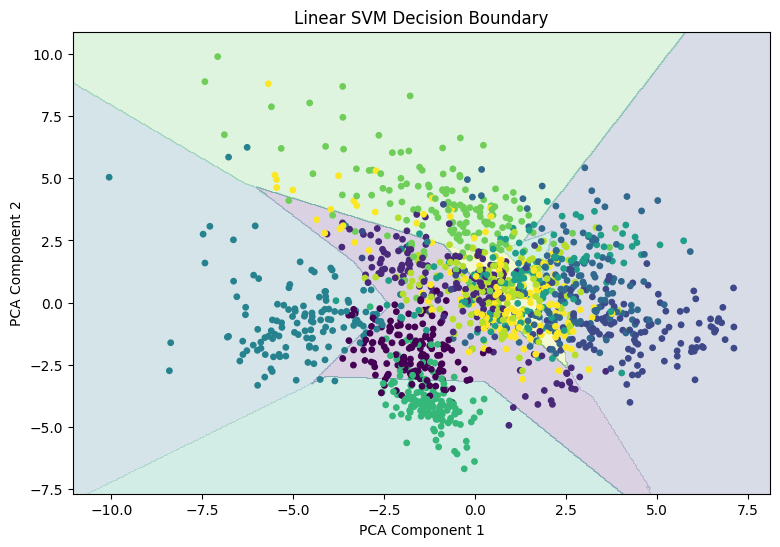

In [67]:
plot_svm_boundary(
    linear_2d,
    X_2D,
    y_train,
    "Linear SVM Decision Boundary"
)

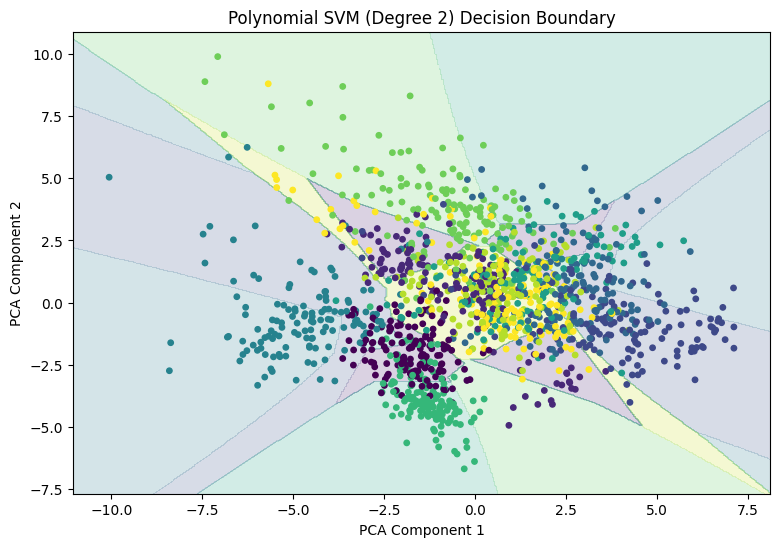

In [68]:
plot_svm_boundary(
    poly_2d,
    X_2D,
    y_train,
    "Polynomial SVM (Degree 2) Decision Boundary"
)

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best parameters: {'C': 10, 'gamma': 'scale'}
Best CV F1: 0.9915661605217378


In [72]:
best_rbf = grid.best_estimator_

y_pred = best_rbf.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred, average='macro'))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test F1: 0.9868050255206742
Test Accuracy: 0.9861111111111112


In [73]:
best_rbf = grid.best_estimator_

y_pred_best = best_rbf.predict(X_test)   # X_test if this is your unscaled experiment

print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("Test F1:", f1_score(y_test, y_pred_best, average='macro'))

Test Accuracy: 0.9861111111111112
Test F1: 0.9868050255206742


In [74]:
print(grid.best_estimator_._gamma)

0.0004304938200020348


In [75]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

best_rbf = grid.best_estimator_

y_pred_best = best_rbf.predict(X_test)   # use X_test if your best model was trained unscaled

print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("Test F1:", f1_score(y_test, y_pred_best, average='macro'))

print(classification_report(y_test, y_pred_best))

Test Accuracy: 0.9861111111111112
Test F1: 0.9868050255206742
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.96      0.98      0.97        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.97      0.97      0.97        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



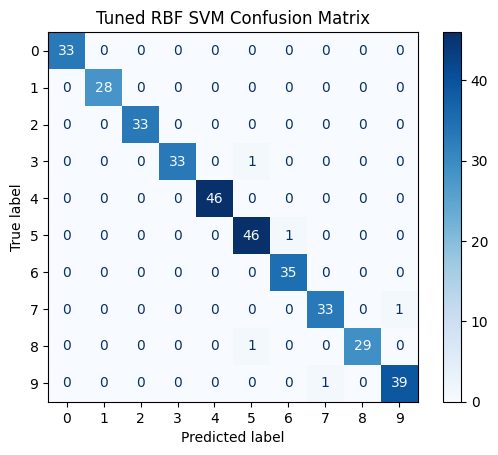

In [76]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap='Blues'
)

plt.title("Tuned RBF SVM Confusion Matrix")
plt.show()

We compared Linear, Polynomial and RBF SVM kernels for handwritten digit classification. Linear SVM achieved strong performance, while Polynomial SVM provided little improvement. RBF SVM performed best, and tuning \(C\) improved its cross-validation F1 score to 0.986. Decision-boundary visualizations demonstrated how kernel choice affects the flexibility of the classifier.